# Set Up

### Installation


In [1]:
%pip install pandas numpy scikit-learn plotly seaborn matplotlib nbformat ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


###  Import Statements


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

# Load the Data

In [4]:
data = pd.read_csv('boston.csv', index_col=0)
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
1,0.01,18.00,2.31,0,0.54,6.58,65.20,4.09,1,296,15.30,396.90,4.98,24.00
2,0.03,0.00,7.07,0,0.47,6.42,78.90,4.97,2,242,17.80,396.90,9.14,21.60
3,0.03,0.00,7.07,0,0.47,7.18,61.10,4.97,2,242,17.80,392.83,4.03,34.70
4,0.03,0.00,2.18,0,0.46,7.00,45.80,6.06,3,222,18.70,394.63,2.94,33.40
5,0.07,0.00,2.18,0,0.46,7.15,54.20,6.06,3,222,18.70,396.90,5.33,36.20


### Understand the Boston House Price Dataset

---------------------------

**Characteristics:**  

    :Number of Instances: 506

    :Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

    :Attribute Information (in order):
        1. CRIM     per capita crime rate by town
        2. ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        3. INDUS    proportion of non-retail business acres per town
        4. CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        5. NOX      nitric oxides concentration (parts per 10 million)
        6. RM       average number of rooms per dwelling
        7. AGE      proportion of owner-occupied units built prior to 1940
        8. DIS      weighted distances to five Boston employment centres
        9. RAD      index of accessibility to radial highways
        10. TAX      full-value property-tax rate per $10,000
        11. PTRATIO  pupil-teacher ratio by town
        12. BLACK     1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
        13. LSTAT    % lower status of the population
        14. PRICE     Median value of owner-occupied homes in $1000's
        
    :Missing Attribute Values: None

    :Creator: Harrison, D. and Rubinfeld, D.L.

This is a copy of [UCI ML housing dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/housing/). This dataset was taken from the StatLib library which is maintained at Carnegie Mellon University. You can find the [original research paper here](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y).


# Preliminary Data Exploration

## Data Cleaning

In [5]:
data.duplicated().values.any()

np.False_

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 1 to 506
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [7]:
data = data.rename(columns={'medv': 'price'})

## Descriptive Statistics

In [8]:
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,price
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## Data Visualization

#### House Prices 💰

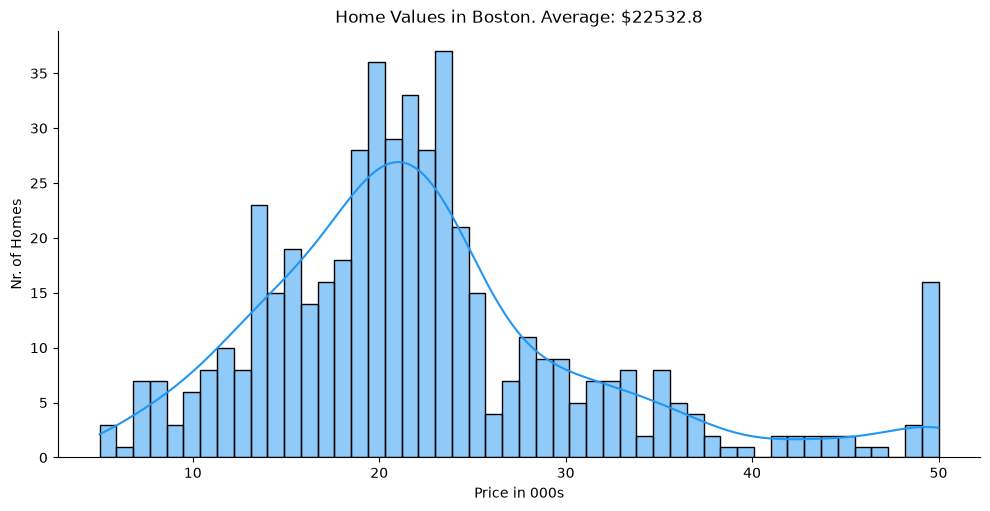

In [9]:
sns.displot(data['price'],
            bins=50,
            aspect=2,
            kde=True,
            color='#2196f3')

plt.title(f'Home Values in Boston. Average: ${(1000*data.price.mean()):.6}')
plt.xlabel('Price in 000s')
plt.ylabel('Nr. of Homes')

plt.show()

#### Distance to Employment - Length of Commute 🚗

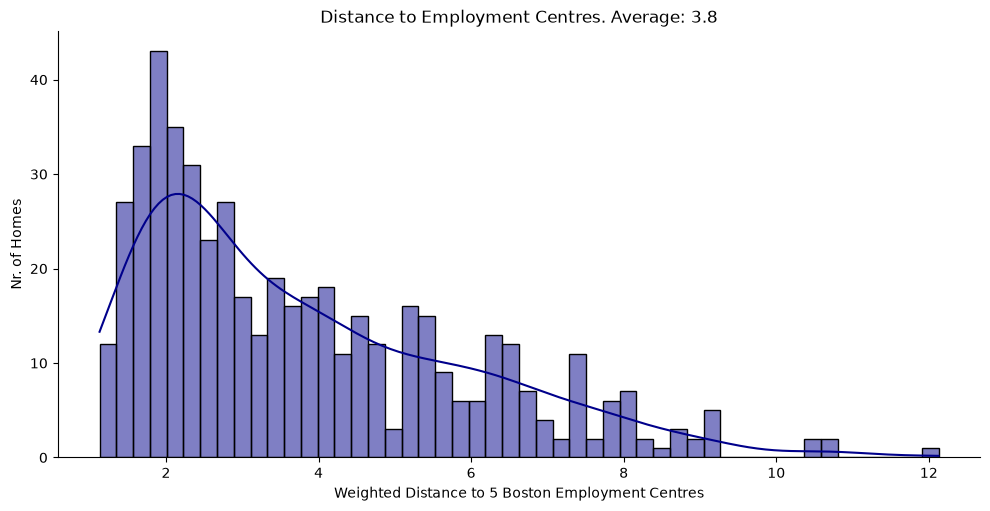

In [10]:
sns.displot(data.dis,
            bins=50,
            aspect=2,
            kde=True,
            color='darkblue')

plt.title(f'Distance to Employment Centres. Average: {(data.dis.mean()):.2}')
plt.xlabel('Weighted Distance to 5 Boston Employment Centres')
plt.ylabel('Nr. of Homes')

plt.show()

#### Number of Rooms

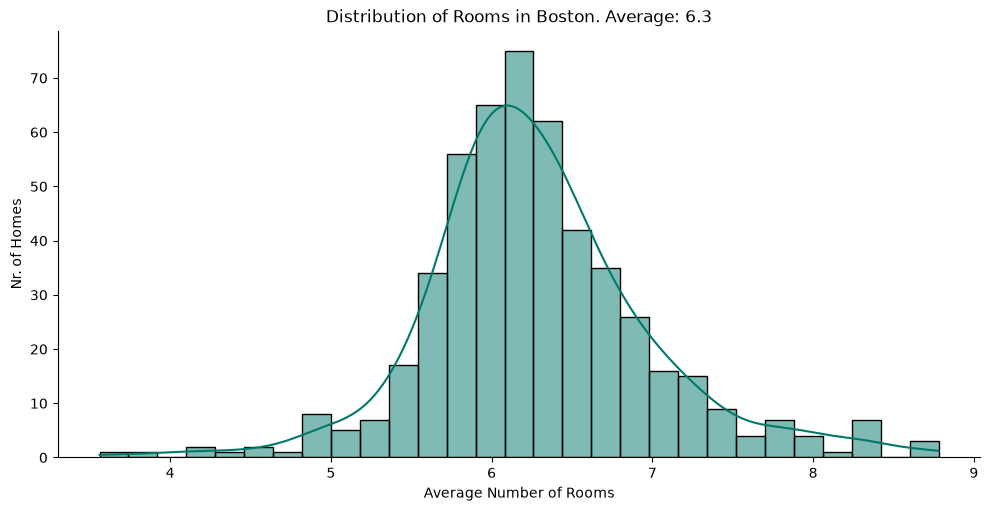

In [11]:
sns.displot(data.rm,
            aspect=2,
            kde=True,
            color='#00796b')

plt.title(f'Distribution of Rooms in Boston. Average: {data.rm.mean():.2}')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Nr. of Homes')

plt.show()

#### Access to Highways 🛣

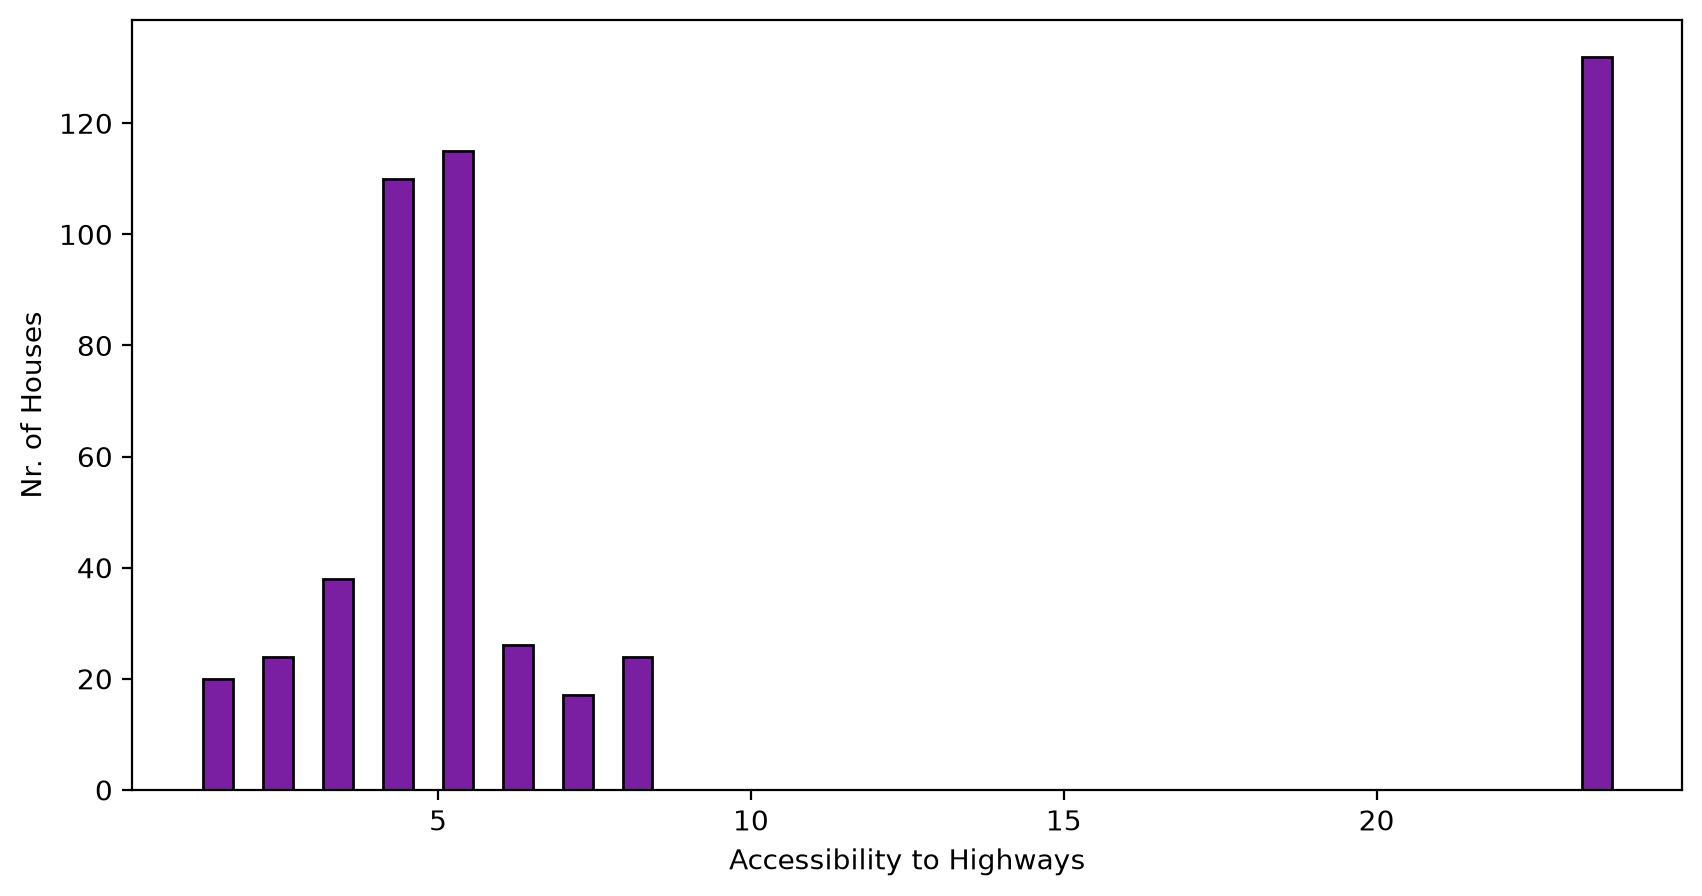

In [12]:
plt.figure(figsize=(10, 5), dpi=200)

plt.hist(data['rad'],
         bins=24,
         ec='black',
         color='#7b1fa2',
         rwidth=0.5)

plt.xlabel('Accessibility to Highways')
plt.ylabel('Nr. of Houses')
plt.show()

#### Next to the River? ⛵️

In [13]:
data['river'] = np.where(data.chas < 1, 'No', 'Yes')
near_river = data.river.value_counts()
bar = px.bar(x=near_river.index,
             y=near_river.values,
             color=near_river.index,
             title='Properties Near Charles River')
bar.update_layout(xaxis_title='Property Located Next to the River?', yaxis_title='Number of Homes', font=dict(size=18))
bar.show()

## Understanding the Relationships in the Data

#### Distance from Employment vs. Pollution

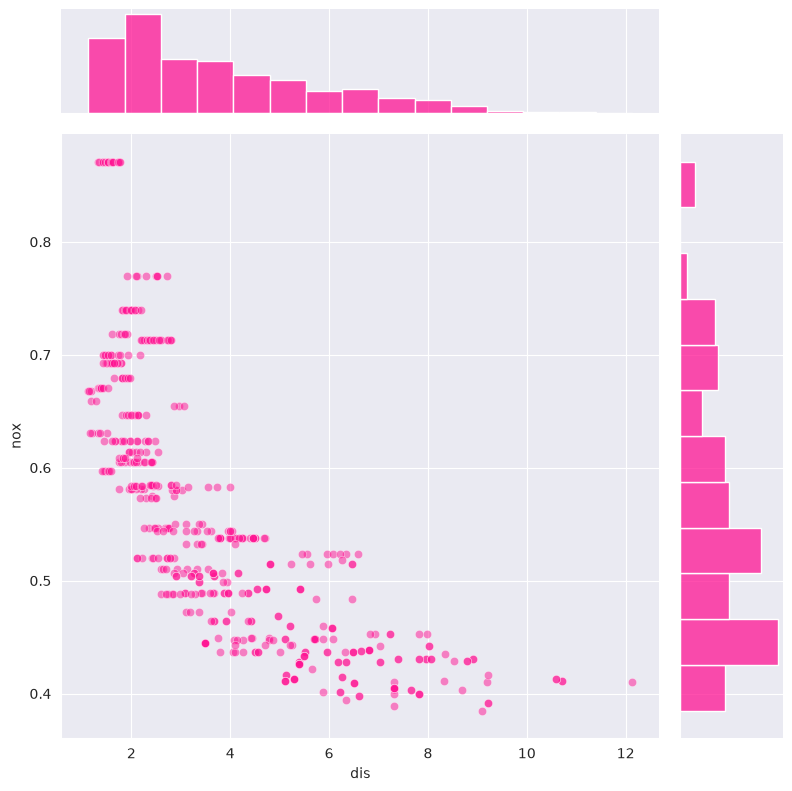

In [15]:
with sns.axes_style('darkgrid'):
  sns.jointplot(x=data.dis, y=data.nox, height=8, kind='scatter', color='deeppink', joint_kws={'alpha':0.5})


#### Proportion of Non-Retail Industry 🏭🏭🏭 versus Pollution

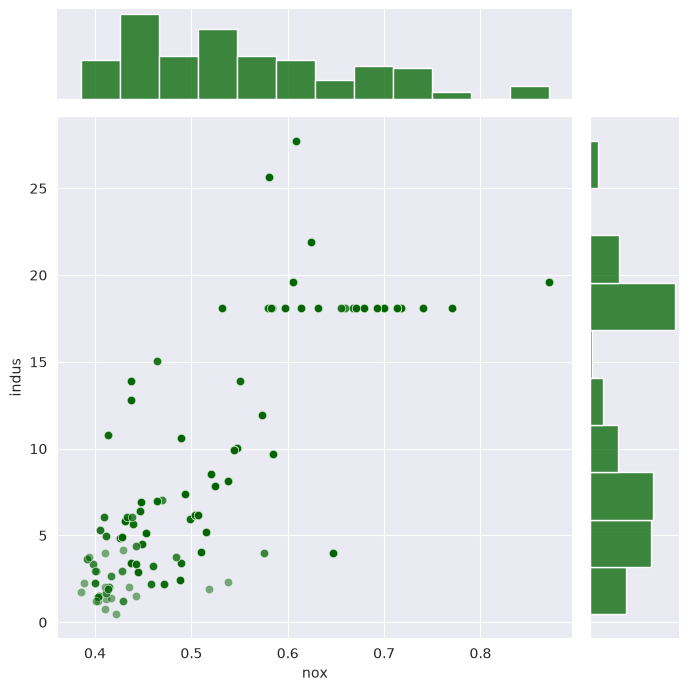

In [16]:
with sns.axes_style('darkgrid'):
  sns.jointplot(x=data.nox, y=data.indus, height=7, color='darkgreen', joint_kws={'alpha':0.5})


#### % of Lower Income Population vs Average Number of Rooms

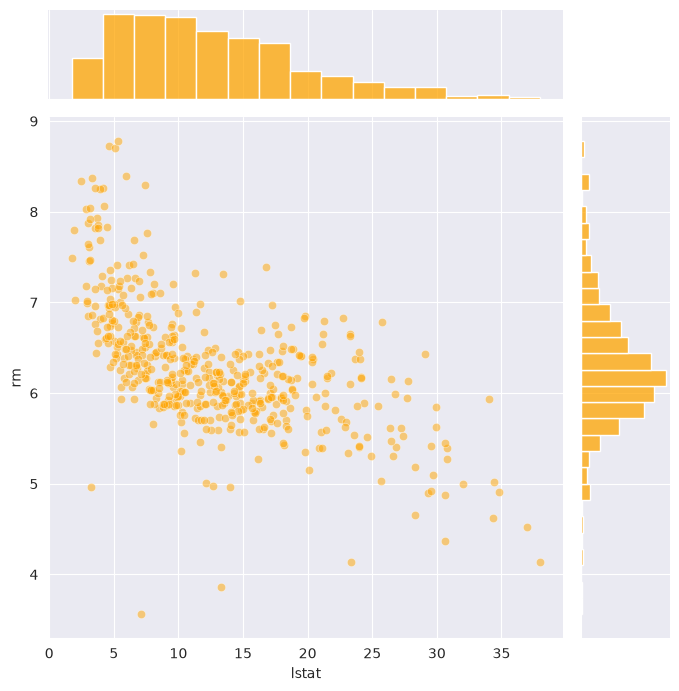

In [17]:
with sns.axes_style('darkgrid'):
  sns.jointplot(x=data.lstat, y=data.rm, height=7, color='orange', joint_kws={'alpha':0.5})


#### % of Lower Income Population versus Home Price

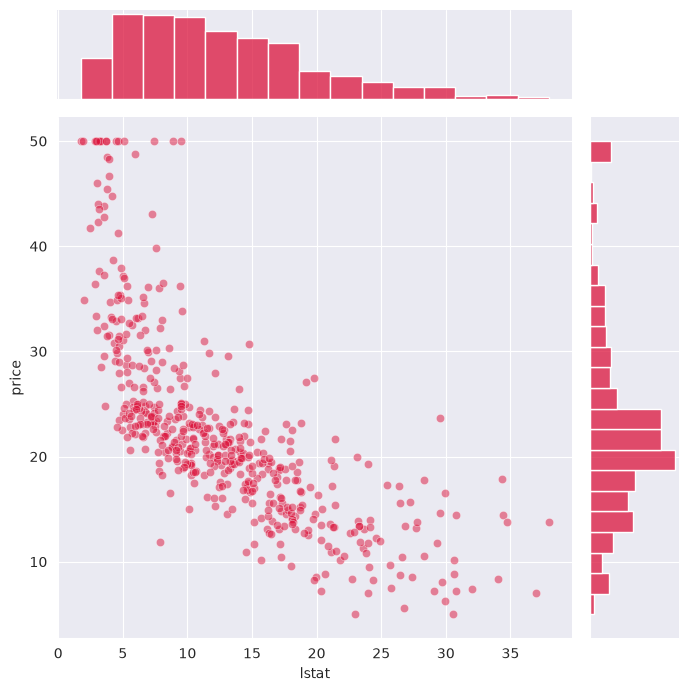

In [18]:
with sns.axes_style('darkgrid'):
  sns.jointplot(x=data.lstat, y=data.price, height=7, color='crimson', joint_kws={'alpha':0.5})


#### Number of Rooms versus Home Value

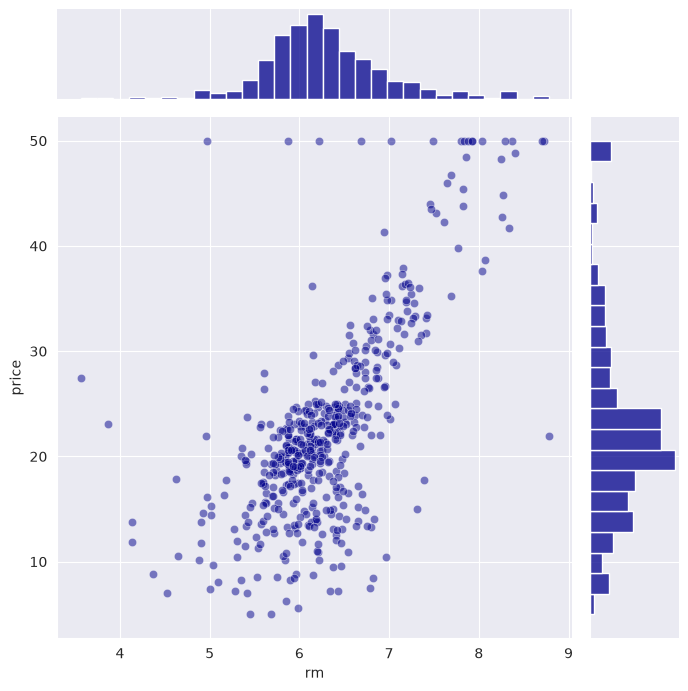

In [19]:
with sns.axes_style('darkgrid'):
  sns.jointplot(x=data.rm, y=data.price, height=7, color='darkblue', joint_kws={'alpha':0.5})


# Split Training & Test Dataset



In [29]:
target = data['price']
features = data.drop(['price', 'river'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    target,
                                                    test_size=0.2,
                                                    random_state=10)

In [30]:
train_pct = 100*len(X_train)/len(features)
print(f'Training data is {train_pct:.3}% of the total data.')

test_pct = 100*X_test.shape[0]/features.shape[0]
print(f'Test data makes up the remaining {test_pct:0.3}%.')

Training data is 79.8% of the total data.
Test data makes up the remaining 20.2%.


# Multivariable Regression

## Linear Regression

### Linear Regression model equation:

$$ pr \hat ice= θ0+θ1crim+θ2zn+θ3indus+θ4chas+ θ5nox+ θ6rm+ θ7age+ θ8dis+ θ9rad+ θ10tax+ θ11ptratio+ θ12bs+θ13lstat$$

In [33]:
regr = LinearRegression()
regr.fit(X_train, y_train)
rsquared = regr.score(X_train, y_train)

print(f'Training data r-squared: {rsquared:.2}')

Training data r-squared: 0.75


### Evaluate the Coefficients of the Model



In [32]:
regr_coef = pd.DataFrame(data=regr.coef_, index=X_train.columns, columns=['Coefficient'])
regr_coef

,Coefficient
crim,-0.13
zn,0.06
indus,-0.01
chas,1.97
nox,-16.27
rm,3.11
age,0.02
dis,-1.48
rad,0.30
tax,-0.01


In [35]:
premium = regr_coef.loc['rm'].values[0] * 1000  # i.e., ~3.11 * 1000
print(f'The price premium for having an extra room is ${premium:.5}')

The price premium for having an extra room is $3108.5


### Analyse the Estimated Values & Regression Residuals

In [43]:
predicted_values = regr.predict(X_train)
residuals = (y_train - predicted_values)

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
C:\Users\lawal\AppData\Local\Temp\ipykernel_10072\1959719211.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
C:\Users\lawal\AppData\Local\Temp\ipykernel_10072\1959719211.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)


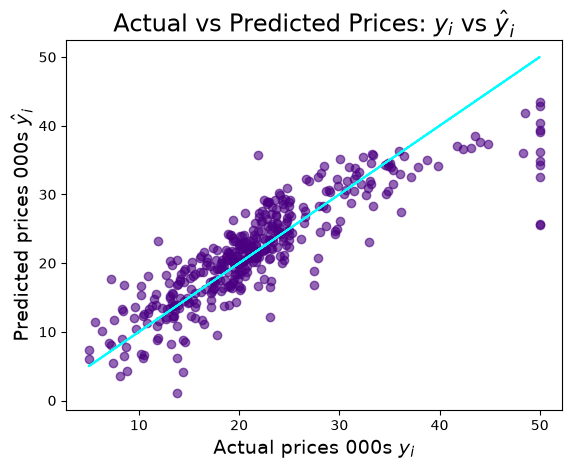

In [44]:
# Regression of Actual vs. Predicted Prices
plt.figure(dpi=100)
plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Predicted prices 000s $\hat y _i$', fontsize=14)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
C:\Users\lawal\AppData\Local\Temp\ipykernel_10072\1450164539.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)


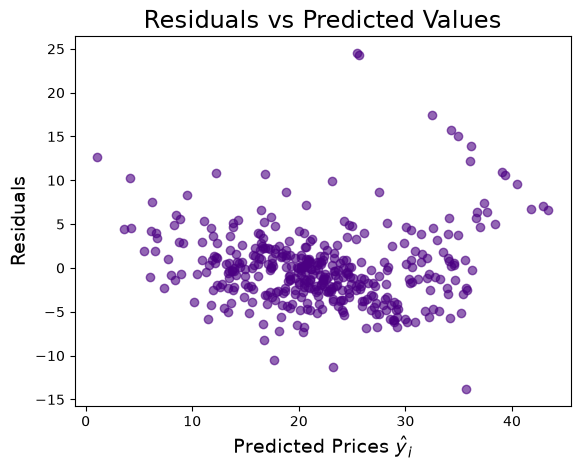

In [45]:
# Residuals vs Predicted values
plt.figure(dpi=100)
plt.scatter(x=predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title('Residuals vs Predicted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

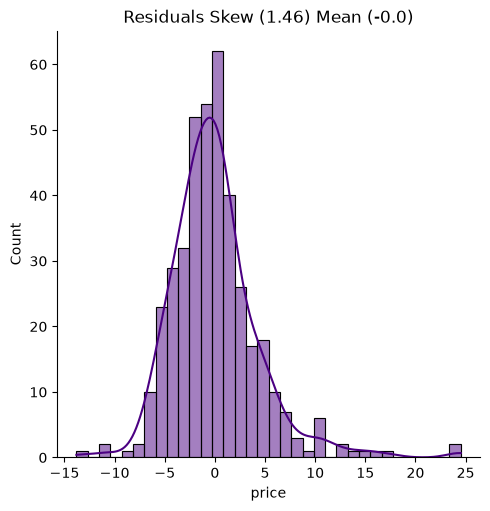

In [46]:
resid_mean = round(residuals.mean(), 2)
resid_skew = round(residuals.skew(), 2)

sns.displot(residuals, kde=True, color='indigo')
plt.title(f'Residuals Skew ({resid_skew}) Mean ({resid_mean})')
plt.show()

### Data Transformations for a Better Fit



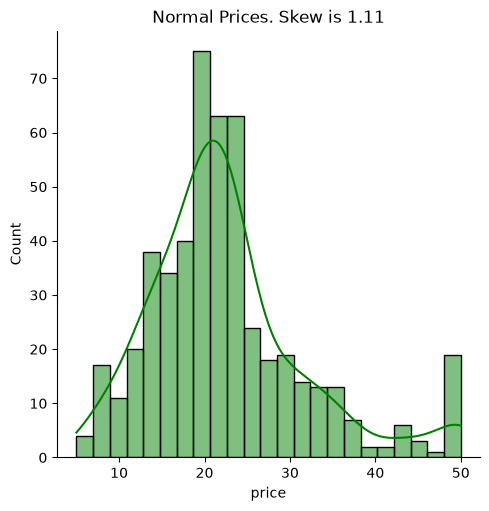

In [47]:
tgt_skew = data['price'].skew()
sns.displot(data['price'], kde='kde', color='green')
plt.title(f'Normal Prices. Skew is {tgt_skew:.3}')
plt.show()

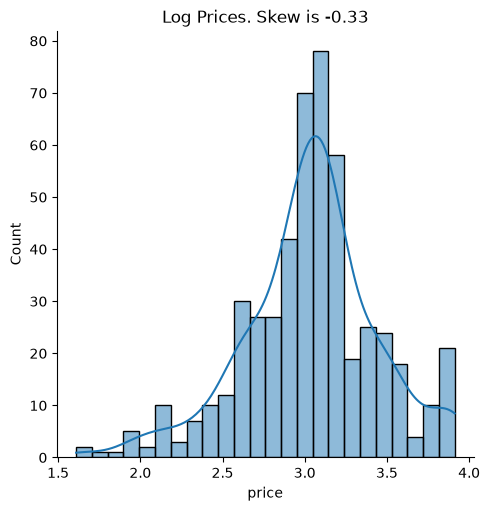

In [41]:
y_log = np.log(data['price'])
sns.displot(y_log, kde=True)
plt.title(f'Log Prices. Skew is {y_log.skew():.3}')
plt.show()

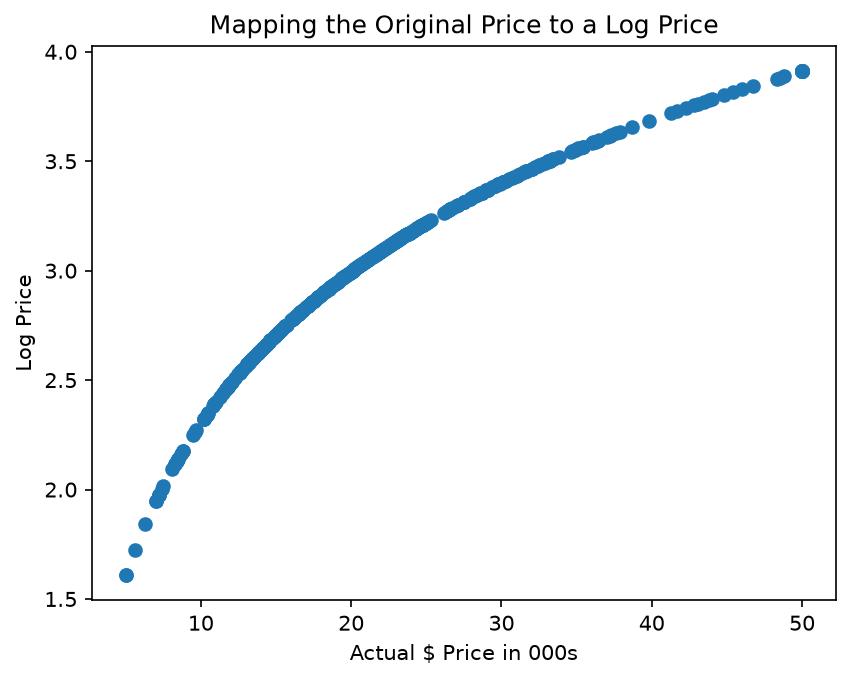

In [42]:
plt.figure(dpi=150)
plt.scatter(data.price, np.log(data.price))

plt.title('Mapping the Original Price to a Log Price')
plt.ylabel('Log Price')
plt.xlabel('Actual $ Price in 000s')
plt.show()

## Regression using Log Prices

New model equation:

$$ \log (PR \hat ICE) = θ0+θ1CRIM+θ2ZN+θ3INDUS+θ4CHAS+θ5NOX+θ6RM+θ7AGE+θ8DIS+θ9RAD+θ10TAX+θ11PTRATIO+θ12BS+θ13LSTAT$$


In [48]:
new_target = np.log(data['price'])
features = data.drop(['price', 'river'], axis=1)

X_train, X_test, log_y_train, log_y_test = train_test_split(features,
                                                    new_target,
                                                    test_size=0.2,
                                                    random_state=10)

log_regr = LinearRegression()
log_regr.fit(X_train, log_y_train)
log_rsquared = log_regr.score(X_train, log_y_train)

log_predictions = log_regr.predict(X_train)
log_residuals = (log_y_train - log_predictions)

print(f'Training data r-squared: {log_rsquared:.2}')

Training data r-squared: 0.79


### Evaluating Coefficients with Log Prices



In [49]:
log_regr_coef = pd.DataFrame(data=log_regr.coef_, index=X_train.columns, columns=['Coefficient'])
log_regr_coef

,Coefficient
crim,-0.01
zn,0.00
indus,0.00
chas,0.08
nox,-0.70
rm,0.07
age,0.00
dis,-0.05
rad,0.01
tax,-0.00


### Regression with Log Prices & Residual Plots



<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:27: SyntaxWarning: invalid escape sequence '\h'
C:\Users\lawal\AppData\Local\Temp\ipykernel_10072\3121911351.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared:.2})', fontsize=17)
C:\Users\lawal\AppData\Local\Temp\ipykernel_10072\3121911351.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Prediced Log Prices $\hat y _i$', fontsize=1

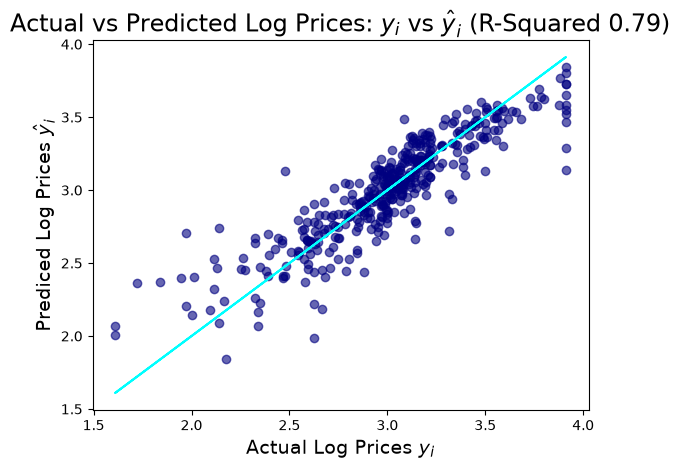

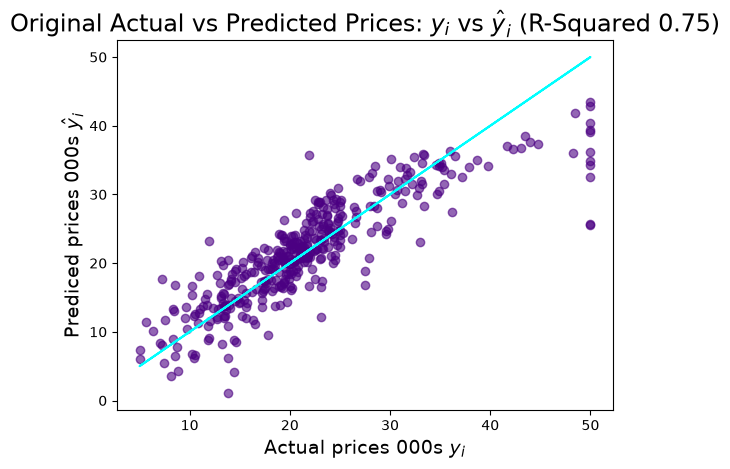

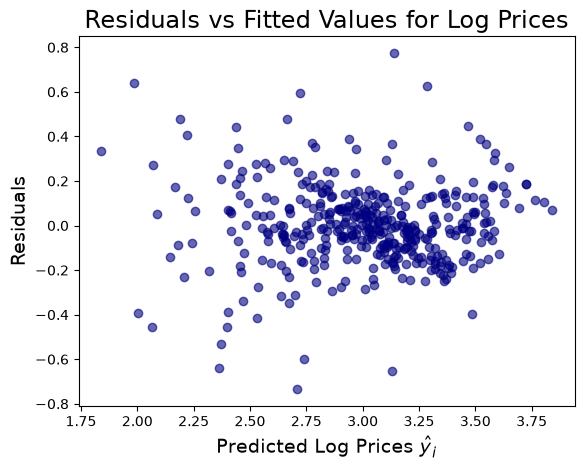

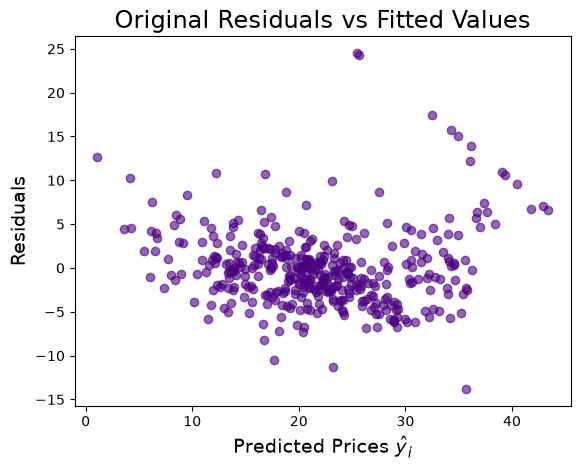

In [50]:
# Graph of Actual vs. Predicted Log Prices
plt.scatter(x=log_y_train, y=log_predictions, c='navy', alpha=0.6)
plt.plot(log_y_train, log_y_train, color='cyan')
plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared:.2})', fontsize=17)
plt.xlabel('Actual Log Prices $y _i$', fontsize=14)
plt.ylabel('Prediced Log Prices $\hat y _i$', fontsize=14)
plt.show()

# Original Regression of Actual vs. Predicted Prices
plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(f'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared {rsquared:.3})', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values (Log prices)
plt.scatter(x=log_predictions, y=log_residuals, c='navy', alpha=0.6)
plt.title('Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.scatter(x=predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title('Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()



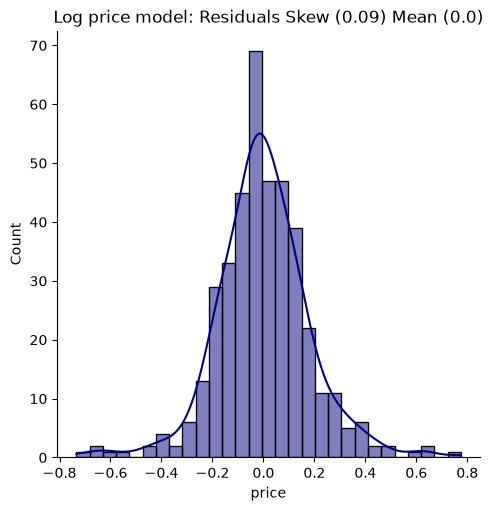

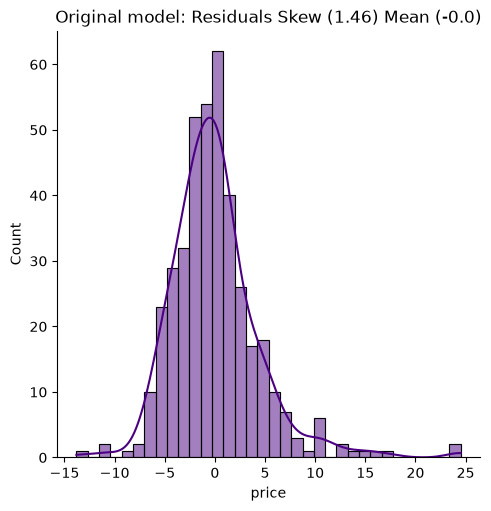

In [51]:
# Distribution of Residuals (log prices) - checking for normality
log_resid_mean = round(log_residuals.mean(), 2)
log_resid_skew = round(log_residuals.skew(), 2)

sns.displot(log_residuals, kde=True, color='navy')
plt.title(f'Log price model: Residuals Skew ({log_resid_skew}) Mean ({log_resid_mean})')
plt.show()

sns.displot(residuals, kde=True, color='indigo')
plt.title(f'Original model: Residuals Skew ({resid_skew}) Mean ({resid_mean})')
plt.show()

## Compare Out of Sample Performance



In [52]:
print(f'Original Model Test Data r-squared: {regr.score(X_test, y_test):.2}')
print(f'Log Model Test Data r-squared: {log_regr.score(X_test, log_y_test):.2}')

Original Model Test Data r-squared: 0.67
Log Model Test Data r-squared: 0.74


# Predict a Property's Value 

The preferred model's equation:

$$ \log (pr \hat ice) = θ0+θ1crim+θ2zn+θ3indus+θ4chas+θ5nox+θ6rm+θ7age+θ8dis+θ9rad+θ10tax+θ11ptratio+θ12bs+θ13lstat$$

The average property has the mean value for all its charactistics:

In [56]:
# Starting Point: Average Values in the Dataset
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)),
                              columns=features.columns)
property_stats

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


Predict how much the average property is worth using the stats above. What is the log price estimate and what is the dollar estimate?

In [57]:
# Make prediction
log_estimate = log_regr.predict(property_stats)[0]
print(f'The log price estimate is ${log_estimate:.3}')

# Convert Log Prices to Acutal Dollar Values
# dollar_est = np.e**log_estimate * 1000
# or use
dollar_est = np.exp(log_estimate) * 1000
print(f'The property is estimated to be worth ${dollar_est:.6}')

The log price estimate is $3.03
The property is estimated to be worth $20703.2


Keeping the average values for CRIM, RAD, INDUS and others, value a property with the following characteristics:

In [63]:
# Define Property Characteristics
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.nox.quantile(q=0.75) # high
amount_of_poverty =  data.lstat.quantile(q=0.25) # low

In [60]:
# Set Property Characteristics
property_stats['rm'] = nr_rooms
property_stats['ptratio'] = students_per_classroom
property_stats['dis'] = distance_to_town

if next_to_river:
    property_stats['chas'] = 1
else:
    property_stats['chas'] = 0

property_stats['nox'] = pollution
property_stats['lstat'] = amount_of_poverty

In [61]:
# Make prediction
log_estimate = log_regr.predict(property_stats)[0]
print(f'The log price estimate is ${log_estimate:.3}')

# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate * 1000
print(f'The property is estimated to be worth ${dollar_est:.6}')

The log price estimate is $3.25
The property is estimated to be worth $25792.0


# Save Model

In [62]:
import joblib

joblib.dump(log_regr, 'log_regr_model.pkl')

['log_regr_model.pkl']